In [6]:
%load_ext autoreload
%autoreload 2

import numpy as np
from scipy.stats import entropy
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from helper_function import fisher_info, solve_pmle, simplex, compute_r_nk

sns.set()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Code for Figure 2

In [2]:

def compute_simplex_atoms(C, alpha, thetas, weights):
    k = len(C)
    n = sum(C)

    thetas = np.asarray(thetas, float)
    weights = np.asarray(weights, float)

    rs = compute_r_nk(n, k, alpha, thetas, theta_0=np.min(thetas))
    denom = sum(rs*weights)

    integrand_1 = 1/(1+thetas/n)
    num_1 = sum(rs*integrand_1*weights)
    ratio_1 = 1/n * num_1/denom

    integrand_2 = (1+thetas/k/alpha)/(1+thetas/n)
    num_2 = sum(rs * integrand_2 * weights)
    ratio_2 = k * alpha/n * num_2/denom
    
    simp = np.zeros(k+1)
        
    simp[:k] = (C-alpha) * ratio_1
    simp[k] =  ratio_2
    return simp


def compute_simplex_mc(C, alpha, sampler, M=2000):
    k = len(C)
    n = sum(C)
    rng = np.random.default_rng(0)
    thetas = sampler(rng, M)

    rs = compute_r_nk(n, k, alpha, thetas)
    denom = np.mean(rs)

    integrand_1 = 1/(1+thetas/n)
    num_1 = np.mean(rs*integrand_1)
    ratio_1 = 1/n * num_1/denom

    integrand_2 = (1+thetas/k/alpha)/(1+thetas/n)
    num_2 = np.mean(rs * integrand_2)
    ratio_2 = k * alpha/n * num_2/denom
    
    simp = np.zeros(k+1)
        
    simp[:k] = (C-alpha) * ratio_1
    simp[k] =  ratio_2
    return simp

def run_atoms(alpha, N, seed, thetas, weights):
    rng = np.random.default_rng(seed)
    C = np.zeros(N, dtype=np.int64)
    # Ks = np.empty(N, dtype=np.int64)

    C[0] = 1
    # Ks[0] = 1
    k = 1

    for _ in range(1, N):
        p = compute_simplex_atoms(C[:k], alpha, thetas, weights)
        s = np.searchsorted(np.cumsum(p), rng.random())
        if s == k:
            k += 1
        C[s] += 1
        # Ks[m] = k

    mle = solve_pmle(C[:k])
    p = compute_simplex_atoms(C[:k], alpha, thetas, weights)
    p_hat = simplex(C[:k], mle)

    tv = np.sum(np.abs(p-p_hat))/2
    kl = entropy(pk=p_hat, qk=p)

    finfo = fisher_info(alpha)
    # K = Ks[-1]

    return {
        'mle':mle, 
        'tv':tv, 
        'kl':kl,
        'normalized_mle': np.sqrt(k*finfo) * (mle-alpha),
        'normalized_tv': N * np.sqrt(finfo/k) * tv,
        'normalized_kl': 2 * N/alpha * kl,
        'alpha': alpha,
        'seed': seed,
        }

def run_mc(alpha, N, seed, sampler):
    rng = np.random.default_rng(seed)
    C = np.zeros(N, dtype=np.int64)
    # Ks = np.empty(N, dtype=np.int64)

    C[0] = 1
    # Ks[0] = 1
    k = 1

    for _ in range(1, N):
        p = compute_simplex_mc(C[:k], alpha, sampler)
        # assert np.isclose(sum(p), 1)
        s = np.searchsorted(np.cumsum(p), rng.random())
        if s == k:
            k += 1

        C[s] += 1
        # Ks[m] = k

    mle = solve_pmle(C[:k])
    p = compute_simplex_mc(C[:k], alpha, sampler)
    p_hat = simplex(C[:k], mle)
    tv = np.sum(np.abs(p-p_hat))/2
    kl = entropy(pk=p_hat, qk=p)

    finfo = fisher_info(alpha)
    # K = Ks[-1]
    return {
        'mle':mle, 
        'tv':tv, 
        'kl':kl,
        'normalized_mle': np.sqrt(k*finfo) * (mle-alpha),
        'normalized_tv': N * np.sqrt(finfo/k) * tv,
        'normalized_kl': 2 * N/alpha * kl,
        'alpha': alpha,
        'seed': seed,
       }

def sampler_uniform(a, b):
    def _s(rng, M):
        return rng.uniform(a, b, size=M)
    return _s

def sampler_gauss():
    def _s(rng, M):
        return np.abs(rng.normal(size=M))
    return _s

def sampler_cauchy():
    def _s(rng, M):
        return np.abs(rng.standard_cauchy(size=M))
    return _s

def sampler_t(df):
    def _s(rng, M):
        return np.abs(rng.standard_t(df=df, size=M))
    return _s

def sampler_dist(dist, a=None, b=None, df=None):
    if dist=='uniform':
        return sampler_uniform(a, b)
    elif dist=='gauss':
        return sampler_gauss()
    elif dist=='cauchy':
        return sampler_cauchy()
    elif dist=='t':
        return sampler_t(df)



In [5]:
N = 20000
alpha = 0.8
seeds = range(0, 1000)
dfs = []

Dirac measure

In [4]:
thetas = [0]
weights = [1]*len(thetas)
params = [{'alpha':alpha, 'N':N, 'seed':seed, 'thetas':thetas, 'weights':weights}
          for seed in seeds
          ]

print(len(params))
data = Parallel(n_jobs=20, verbose=12)(
        delayed(run_atoms)(**d) for d in params)

df = pd.DataFrame(data)
df.to_csv(f"data/f-div/atom_seed_{len(seeds)}_N_{N}_alpha_{alpha}_thetas_{str(thetas)}.csv", index=False)

dfs.append(df)

100


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done   2 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done   3 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done   4 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done   5 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done   6 tasks      | elapsed:    1.0s
[Parallel(n_jobs=20)]: Done   7 tasks      | elapsed:    1.1s
[Parallel(n_jobs=20)]: Done   8 tasks      | elapsed:    1.1s
[Parallel(n_jobs=20)]: Done   9 tasks      | elapsed:    1.1s
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    1.1s
[Parallel(n_jobs=20)]: Done  11 tasks      | elapsed:    1.1s
[Parallel(n_jobs=20)]: Done  12 tasks      | elapsed:    1.1s
[Parallel(n_jobs=20)]: Done  13 tasks      | elapsed:    1.1s
[Parallel(n_jobs=20)]: Done  14 tasks      | elapsed:    1.1s
[Parallel(n_jobs=20)]: Done  15 tasks      | elapsed:  

In [15]:
thetas = [0, 3]
weights = [1]*len(thetas)
params = [{'alpha':alpha, 'N':N, 'seed':seed, 'thetas':thetas, 'weights':weights}
          for seed in seeds
          ]
data = Parallel(n_jobs=20, verbose=12)(
        delayed(run_atoms)(**d) for d in params)
df = pd.DataFrame(data)
df.to_csv(f"data/f-div/atom_seed_{len(seeds)}_N_{N}_alpha_{alpha}_thetas_{str(thetas)}.csv", index=False)

dfs.append(df)


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    1.2s
[Parallel(n_jobs=20)]: Done   2 tasks      | elapsed:    2.3s
[Parallel(n_jobs=20)]: Done   3 tasks      | elapsed:    2.7s
[Parallel(n_jobs=20)]: Done   4 tasks      | elapsed:    3.0s
[Parallel(n_jobs=20)]: Done   5 tasks      | elapsed:    3.0s
[Parallel(n_jobs=20)]: Done   6 tasks      | elapsed:    3.2s
[Parallel(n_jobs=20)]: Done   7 tasks      | elapsed:    3.2s
[Parallel(n_jobs=20)]: Done   8 tasks      | elapsed:    3.3s
[Parallel(n_jobs=20)]: Done   9 tasks      | elapsed:    3.4s
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    3.6s
[Parallel(n_jobs=20)]: Done  11 tasks      | elapsed:    3.7s
[Parallel(n_jobs=20)]: Done  12 tasks      | elapsed:    3.7s
[Parallel(n_jobs=20)]: Done  13 tasks      | elapsed:    3.9s
[Parallel(n_jobs=20)]: Done  14 tasks      | elapsed:    3.9s
[Parallel(n_jobs=20)]: Done  15 tasks      | elapsed:  

In [16]:
dist = 'uniform'
sampler = sampler_dist(dist, a=0, b=3)

params = [{'alpha':alpha, 'N':N, 'seed':seed, 'sampler':sampler}
          for seed in seeds
          ]

data = Parallel(n_jobs=20, verbose=12)(
        delayed(run_mc)(**d) for d in params)

df = pd.DataFrame(data)
df.to_csv(f"data/f-div/uniform_seed_{len(seeds)}_N_{N}_alpha_{alpha}.csv", index=False)
dfs.append(df)

[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    5.0s
[Parallel(n_jobs=20)]: Done   2 tasks      | elapsed:    6.0s
[Parallel(n_jobs=20)]: Done   3 tasks      | elapsed:    6.3s
[Parallel(n_jobs=20)]: Done   4 tasks      | elapsed:    6.7s
[Parallel(n_jobs=20)]: Done   5 tasks      | elapsed:    6.7s
[Parallel(n_jobs=20)]: Done   6 tasks      | elapsed:    6.8s
[Parallel(n_jobs=20)]: Done   7 tasks      | elapsed:    6.9s
[Parallel(n_jobs=20)]: Done   8 tasks      | elapsed:    7.2s
[Parallel(n_jobs=20)]: Done   9 tasks      | elapsed:    7.2s
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    7.2s
[Parallel(n_jobs=20)]: Done  11 tasks      | elapsed:    7.3s
[Parallel(n_jobs=20)]: Done  12 tasks      | elapsed:    7.3s
[Parallel(n_jobs=20)]: Done  13 tasks      | elapsed:    7.3s
[Parallel(n_jobs=20)]: Done  14 tasks      | elapsed:    7.3s
[Parallel(n_jobs=20)]: Done  15 tasks      | elapsed:  

In [17]:
dist = 'gauss'
sampler = sampler_dist(dist=dist)

params = [{'alpha':alpha, 'N':N, 'seed':seed, 'sampler':sampler}
          for seed in seeds
          ]

data = Parallel(n_jobs=20, verbose=12)(
        delayed(run_mc)(**d) for d in params)

df = pd.DataFrame(data)
df.to_csv(f"data/f-div/gauss_seed_{len(seeds)}_N_{N}_alpha_{alpha}.csv", index=False)
dfs.append(df)


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    4.7s
[Parallel(n_jobs=20)]: Done   2 tasks      | elapsed:    5.2s
[Parallel(n_jobs=20)]: Done   3 tasks      | elapsed:    5.6s
[Parallel(n_jobs=20)]: Done   4 tasks      | elapsed:    6.2s
[Parallel(n_jobs=20)]: Done   5 tasks      | elapsed:    6.2s
[Parallel(n_jobs=20)]: Done   6 tasks      | elapsed:    6.2s
[Parallel(n_jobs=20)]: Done   7 tasks      | elapsed:    6.3s
[Parallel(n_jobs=20)]: Done   8 tasks      | elapsed:    6.3s
[Parallel(n_jobs=20)]: Done   9 tasks      | elapsed:    6.4s
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    6.7s
[Parallel(n_jobs=20)]: Done  11 tasks      | elapsed:    6.8s
[Parallel(n_jobs=20)]: Done  12 tasks      | elapsed:    6.9s
[Parallel(n_jobs=20)]: Done  13 tasks      | elapsed:    6.9s
[Parallel(n_jobs=20)]: Done  14 tasks      | elapsed:    6.9s
[Parallel(n_jobs=20)]: Done  15 tasks      | elapsed:  

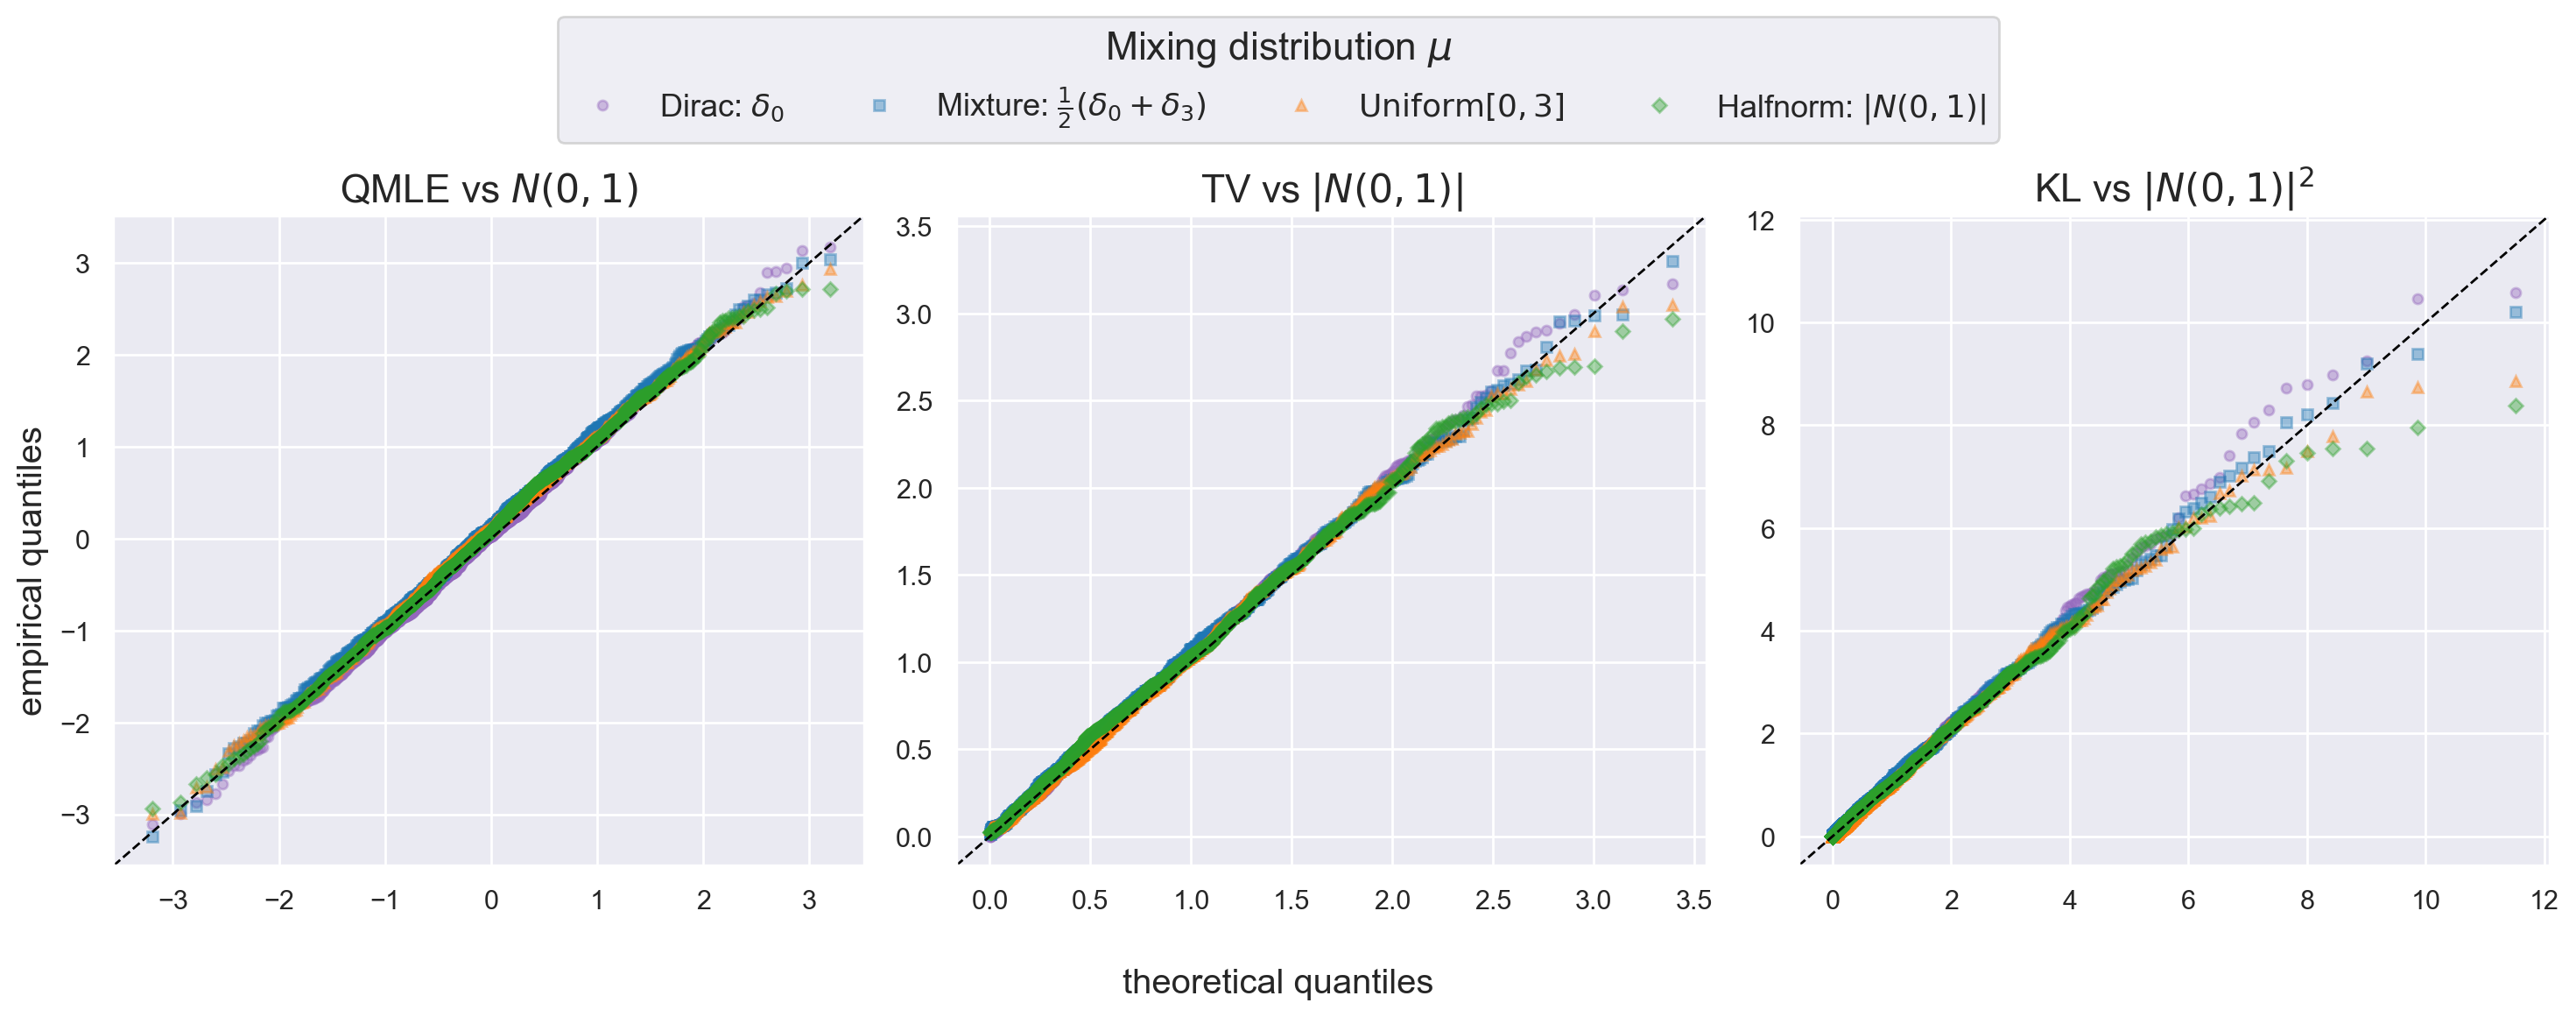

In [18]:
from scipy.stats import probplot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=200)

colors = ["tab:purple", "tab:blue", "tab:orange", "tab:green"]
markers = ["o",   "s",  "^",  "D"]
labels = [
r"Dirac: $\delta_0$",
r"Mixture: $\frac{1}{2} (\delta_0 + \delta_3)$",
r"$\text{Uniform}[0,3]$",
r"Halfnorm: $|N(0,1)|$",
]

mc = 4
alp = 0.4

for i in range(4):
    osm, osr = probplot(dfs[i]['normalized_mle'], dist="norm", fit=False)
    axes[0].plot(
        osm, osr,
        linestyle='None',
        marker=markers[i],
        color=colors[i],
        label=labels[i],
        alpha=alp,
        markersize=mc
    )

    osm, osr = probplot(dfs[i]['normalized_tv'], dist="halfnorm", fit=False)
    axes[1].plot(
        osm, osr,
        linestyle='None',
        marker=markers[i],
        color=colors[i],
        label=labels[i],
        alpha=alp,
        markersize=mc
    )

    osm, osr = probplot(dfs[i]['normalized_kl'], dist="chi2", sparams=(1,), fit=False)
    axes[2].plot(
        osm, osr,
        linestyle='None',
        marker=markers[i],
        color=colors[i],
        label=labels[i],
        alpha=alp,
        markersize=mc
    )

axes[0].set_title(r"QMLE vs $N(0,1)$", fontsize=16)
axes[1].set_title(r"TV vs $|N(0,1)|$", fontsize=16)
axes[2].set_title(r"KL vs $|N(0,1)|^2$", fontsize=16)

# add y=x line to each subplot
for ax in axes:
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])
    ax.plot([lo, hi], [lo, hi], '--', color='black', linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.grid(True)


handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 1.15),
    frameon=True,
    fontsize=13,
    title=r'Mixing distribution $\mu$',
    title_fontsize=16
)

fig.supylabel("empirical quantiles")
fig.supxlabel("theoretical quantiles")

plt.tight_layout()
filename = f"../../spa/fig/qq_atom_seed_{len(seeds)}_N_{N}_alpha_{alpha}_summary.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

### test for t-distribution

In [6]:
N = 20000
alpha = 0.8
seeds = range(0, 1000)
num_test = 1000
degs =[2, 3, 4, 5]
dfs = []
for deg in degs:
        sampler = sampler_dist(dist='t', df=deg)
        params = [{'alpha':alpha, 'N':N, 'seed':seed, 'sampler':sampler, 'num_test':num_test}
                for seed in seeds
                ]
        data = Parallel(n_jobs=20, verbose=12)(
                delayed(run_mc)(**d) for d in params)

        df_tmp = pd.DataFrame(data)
        df_tmp['deg']=deg
        dfs.append(df_tmp)



[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.


[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:    6.3s
[Parallel(n_jobs=20)]: Done   2 tasks      | elapsed:    7.9s
[Parallel(n_jobs=20)]: Done   3 tasks      | elapsed:    8.6s
[Parallel(n_jobs=20)]: Done   4 tasks      | elapsed:    9.0s
[Parallel(n_jobs=20)]: Done   5 tasks      | elapsed:   10.0s
[Parallel(n_jobs=20)]: Done   6 tasks      | elapsed:   10.1s
[Parallel(n_jobs=20)]: Done   7 tasks      | elapsed:   10.2s
[Parallel(n_jobs=20)]: Done   8 tasks      | elapsed:   10.6s
[Parallel(n_jobs=20)]: Done   9 tasks      | elapsed:   10.7s
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:   10.7s
[Parallel(n_jobs=20)]: Done  11 tasks      | elapsed:   11.0s
[Parallel(n_jobs=20)]: Done  12 tasks      | elapsed:   11.0s
[Parallel(n_jobs=20)]: Done  13 tasks      | elapsed:   11.1s
[Parallel(n_jobs=20)]: Done  14 tasks      | elapsed:   11.2s
[Parallel(n_jobs=20)]: Done  15 tasks      | elapsed:   11.5s
[Parallel(n_jobs=20)]: Done  16 tasks      | elapsed:   11.5s
[Paralle

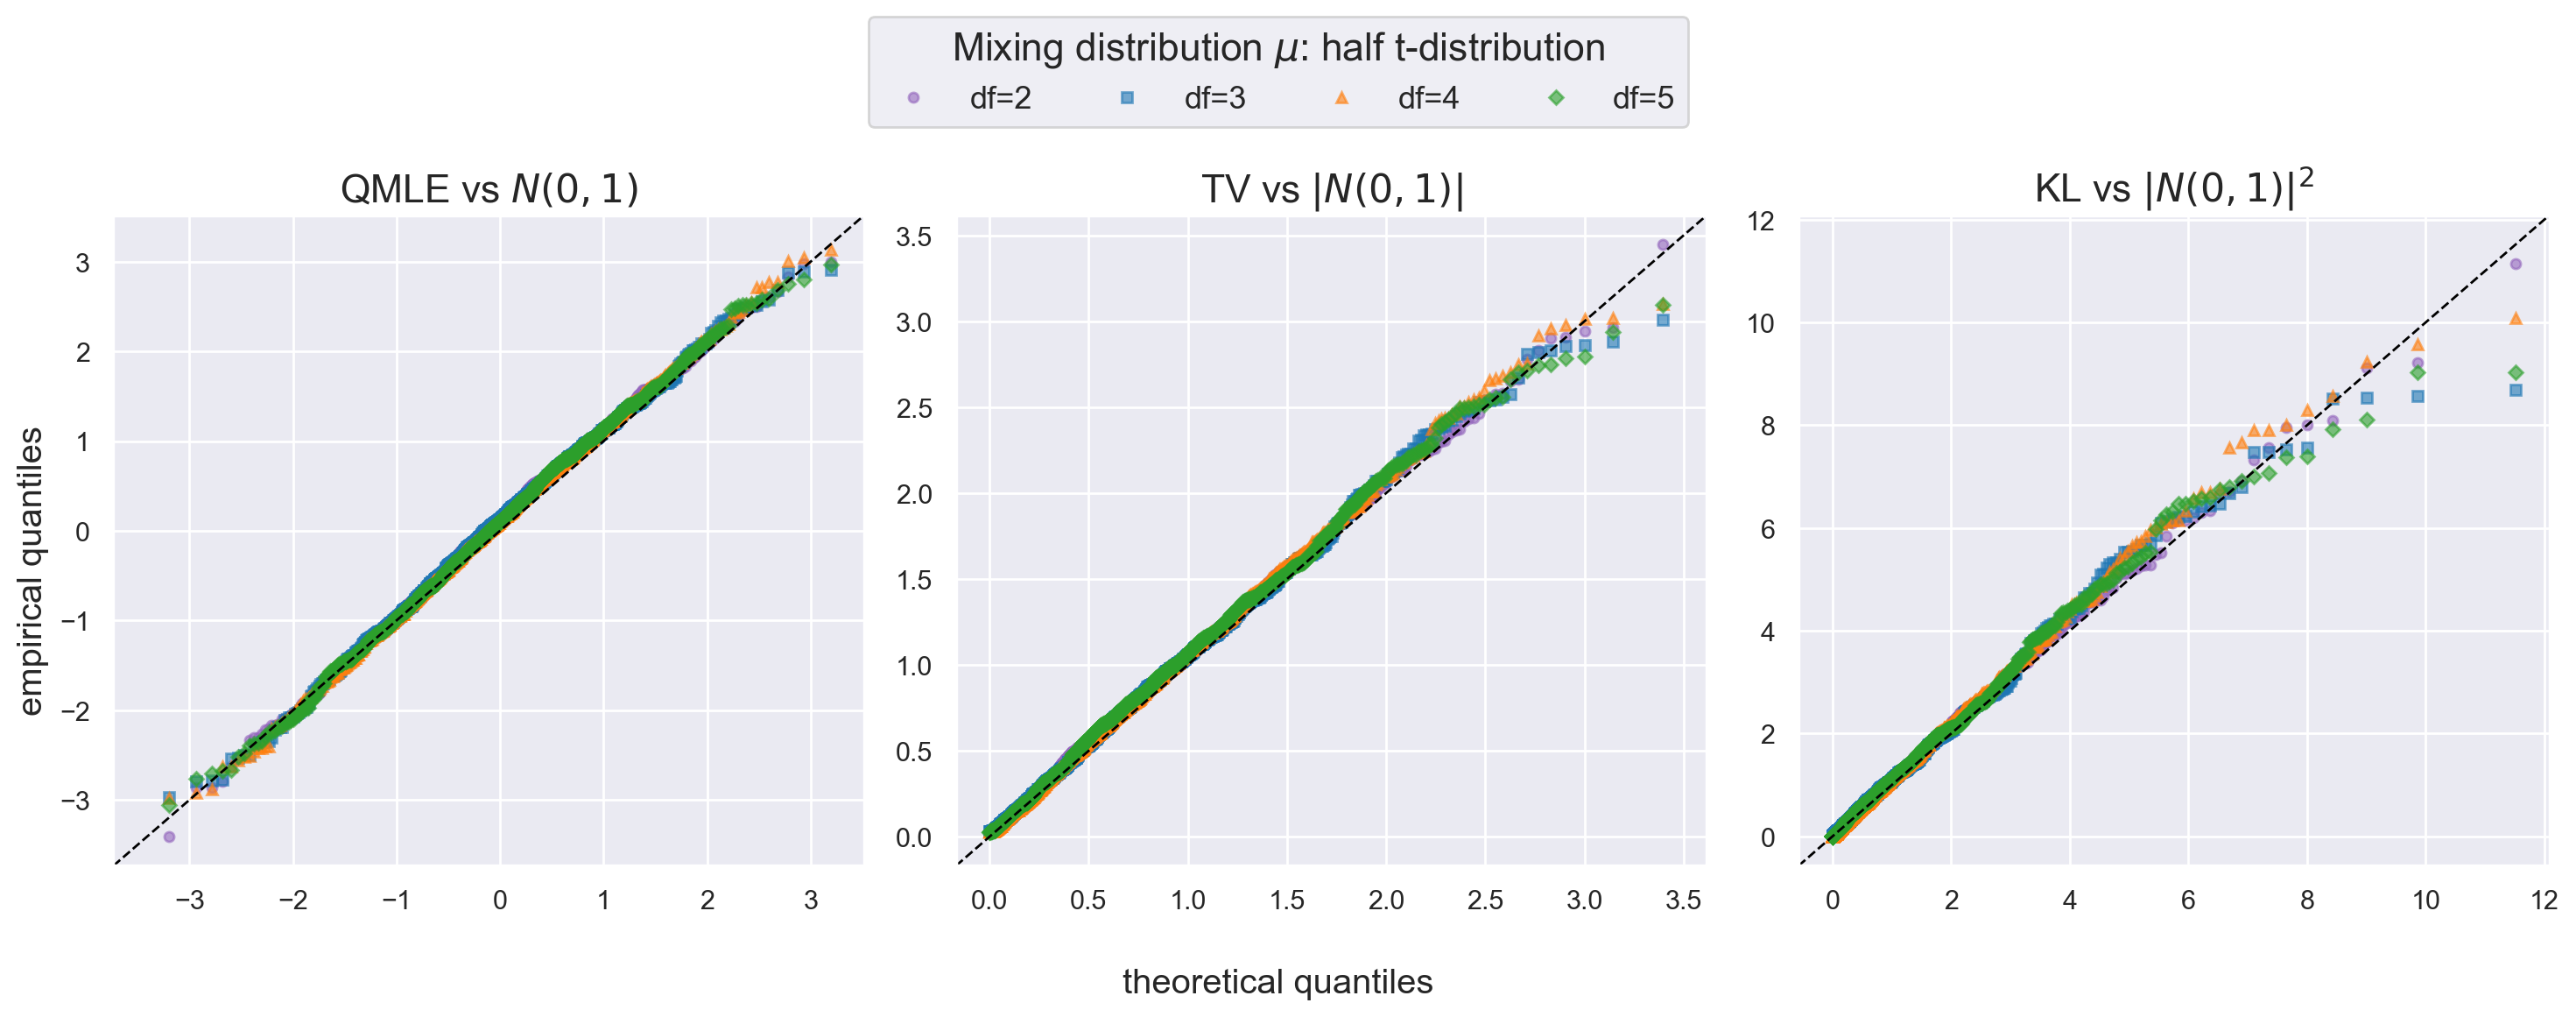

In [7]:
from scipy.stats import probplot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=200)
colors = ["tab:purple", "tab:blue", "tab:orange", "tab:green"]
markers = ["o",  "s",  "^", "D"]

mc = 4
alp = 0.6

for i, deg in enumerate(degs):
    osm, osr = probplot(dfs[i]['normalized_mle'], dist="norm", fit=False)
    axes[0].plot(
        osm, osr,
        linestyle='None',
        marker=markers[i],
        color=colors[i],
        label=f'df={deg}',
        alpha=alp,
        markersize=mc
    )

    osm, osr = probplot(dfs[i]['normalized_tv'], dist="halfnorm", fit=False)
    axes[1].plot(
        osm, osr,
        linestyle='None',
        marker=markers[i],
        color=colors[i],
        label=f'df={deg}',
        alpha=alp,
        markersize=mc
    )

    osm, osr = probplot(dfs[i]['normalized_kl'], dist="chi2", sparams=(1,), fit=False)
    axes[2].plot(
        osm, osr,
        linestyle='None',
        marker=markers[i],
        color=colors[i],
        label=f'df={deg}',
        alpha=alp,
        markersize=mc
    )

axes[0].set_title(r"QMLE vs $N(0,1)$", fontsize=16)
axes[1].set_title(r"TV vs $|N(0,1)|$", fontsize=16)
axes[2].set_title(r"KL vs $|N(0,1)|^2$", fontsize=16)

for ax in axes:
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    lo = min(xlim[0], ylim[0])
    hi = max(xlim[1], ylim[1])
    ax.plot([lo, hi], [lo, hi], '--', color='black', linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.grid(True)

handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 1.15),
    frameon=True,
    fontsize=13,
    title=r'Mixing distribution $\mu$: half t-distribution',
    title_fontsize=16
)

fig.supylabel("empirical quantiles")
fig.supxlabel("theoretical quantiles")

plt.tight_layout()
filename = f"../../spa/fig/qq_atom_seed_{len(seeds)}_N_{N}_alpha_{alpha}_t-dist.png"
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()